# High Dynamic Range images

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

def readImagesAndTimes():
    image_filenames = ['img_0.033.jpg', 'img_0.25.jpg', 'img_2.5.jpg', 'img_15.jpg']

    images = []
    for filename in image_filenames:
        img_bgr = cv2.imread("../Images/hdr/" + filename)
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        images.append(img)

    times = np.array([1/30, 0.25, 2.5, 15], dtype=np.float32)
    
    return images, times
        

## Aligning Images

In [19]:
images, times = readImagesAndTimes()

alignMTB = cv.createAlignMTB()
alignMTB.process(images, images)

## Estimate Camera Response Function

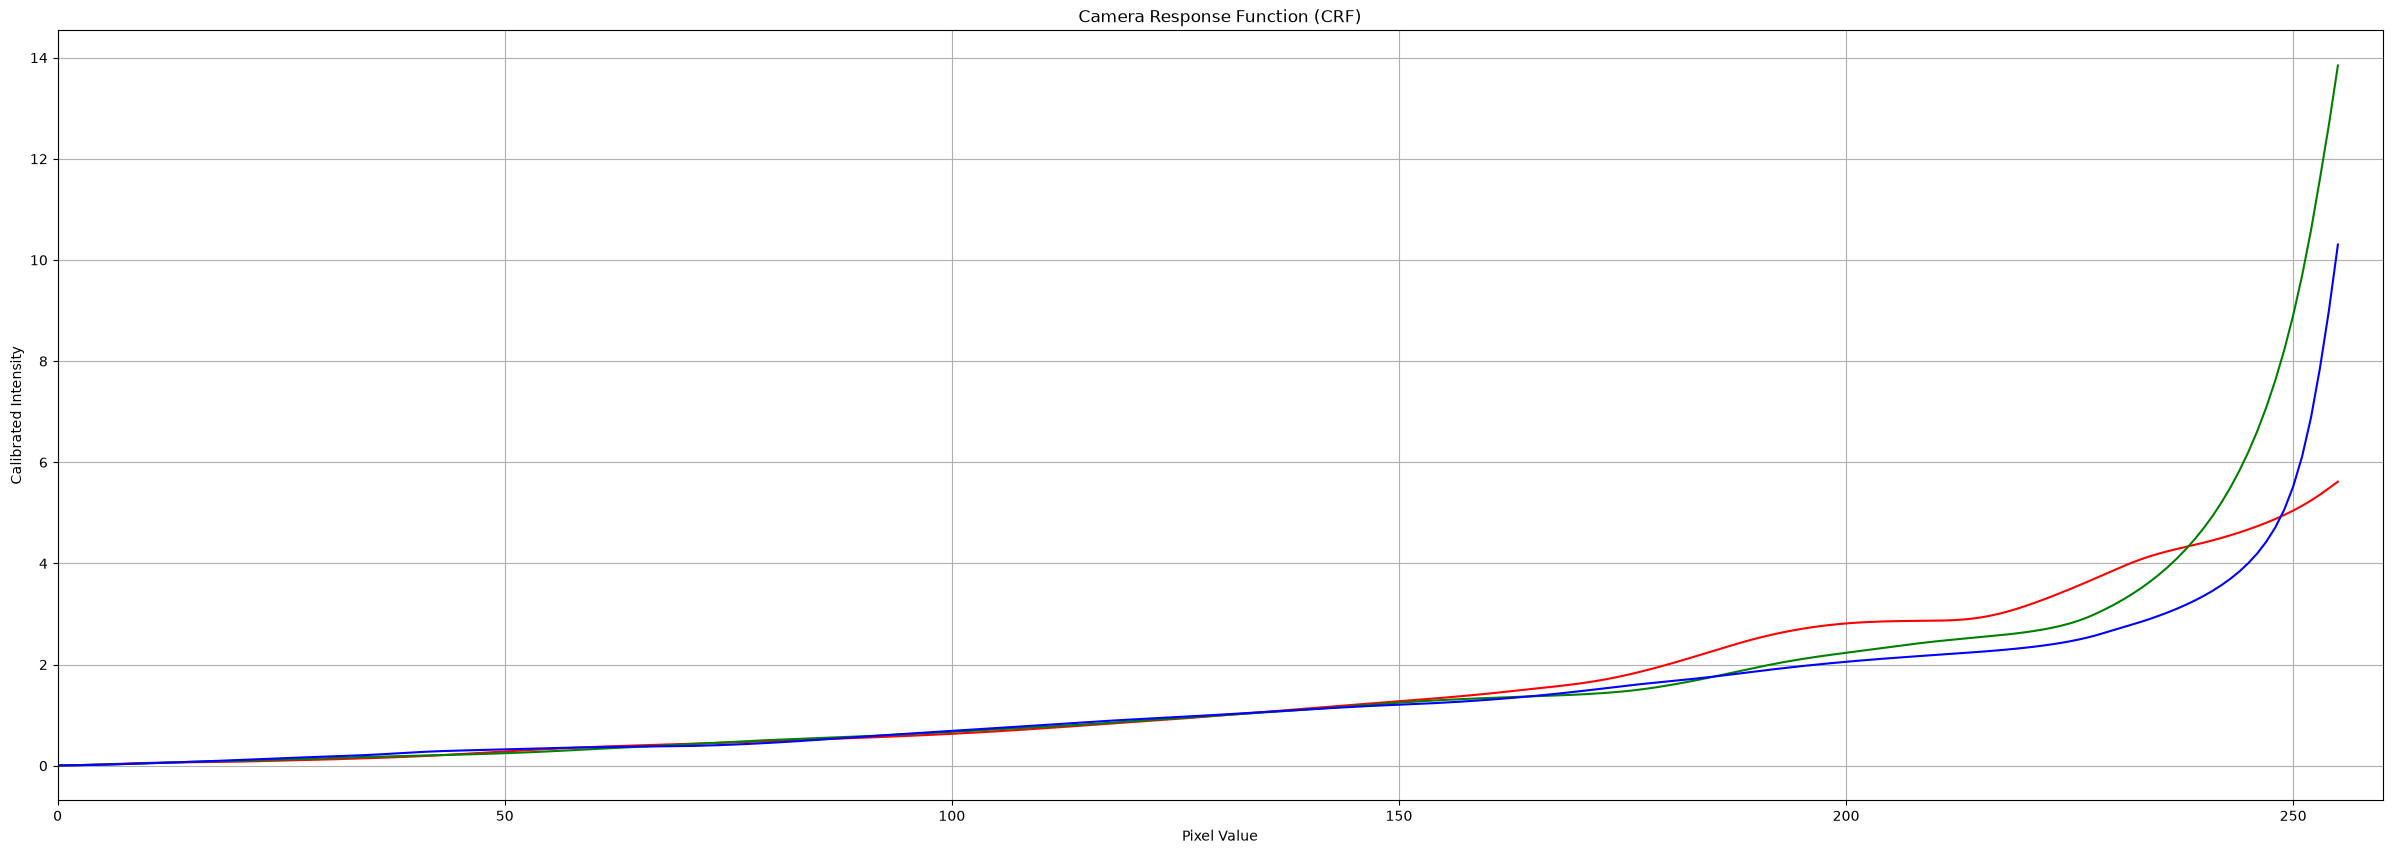

In [20]:
# Magic
calibrateDebevec = cv.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

# Plot CRF
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

plt.figure(figsize=(30, 10))
plt.title('Camera Response Function (CRF)')
plt.xlabel('Pixel Value')
plt.ylabel('Calibrated Intensity')
plt.xlim([0, 260])
plt.grid() 
plt.plot(x, y[:,0], 'r', x , y[:,1], 'g', x, y[:,2], 'b')

## Merge Images

In [21]:
mergeDebevec = cv.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

## Tonemapping
This is necessary because the combined range right now is 0 to infinity, which is hard to contain within 8 bits (0,255). We need to dial it back down respectively.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00038201545..415.36835].


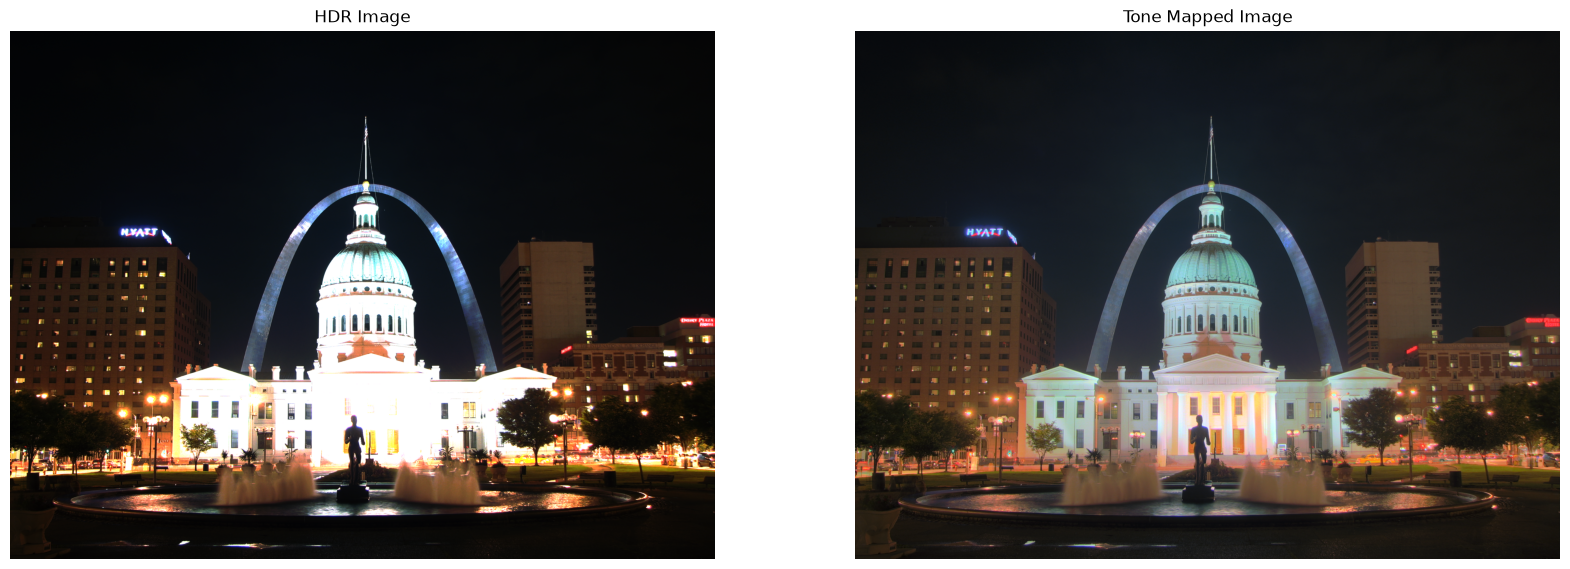

In [27]:
toneMapDrago = cv.createTonemapDrago(1.0, 0.7)
ldrDrago = toneMapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1); plt.imshow(hdrDebevec); plt.title('HDR Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(np.clip(ldrDrago, 0 ,1)); plt.title('Tone Mapped Image'); plt.axis('off')
plt.show()
